In [2]:
# ==========================================================
# Model Comparison - Setup
# ==========================================================

import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from torch.utils.data import Dataset

# ----------------------------------------------------------
# Device
# ----------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# ----------------------------------------------------------
# Classes
# ----------------------------------------------------------

class_names = [
    "Centromere",
    "Golgi",
    "Homogeneous",
    "NuMem",
    "Nucleolar",
    "Speckled"
]

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Device: cpu
Classes: ['Centromere', 'Golgi', 'Homogeneous', 'NuMem', 'Nucleolar', 'Speckled']
Number of classes: 6


In [3]:
# ==========================================================
# Load Already-Trained ResNet50 and DenseNet121
# ==========================================================

RESNET_PATH = "resnet50_best.pth"
DENSENET_PATH = "densenet121_best.pth"

# ----------------------------------------------------------
# ResNet50
# ----------------------------------------------------------

resnet_model = models.resnet50(weights=None)

resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    num_classes
)

resnet_model.load_state_dict(
    torch.load(
        RESNET_PATH,
        map_location=device
    )
)

resnet_model = resnet_model.to(device)
resnet_model.eval()


# ----------------------------------------------------------
# DenseNet121
# ----------------------------------------------------------

densenet_model = models.densenet121(weights=None)

densenet_model.classifier = nn.Linear(
    densenet_model.classifier.in_features,
    num_classes
)

densenet_model.load_state_dict(
    torch.load(
        DENSENET_PATH,
        map_location=device
    )
)

densenet_model = densenet_model.to(device)
densenet_model.eval()


# ----------------------------------------------------------
# Verification
# ----------------------------------------------------------

print("=" * 60)
print("TRAINED MODELS LOADED")
print("=" * 60)

print("ResNet50    : Loaded successfully")
print("DenseNet121 : Loaded successfully")
print("Device      :", device)

TRAINED MODELS LOADED
ResNet50    : Loaded successfully
DenseNet121 : Loaded successfully
Device      : cpu


In [4]:
# ==========================================================
# Load Already-Trained ResNet50 and DenseNet121
# ==========================================================

RESNET_PATH = "resnet50_best.pth"
DENSENET_PATH = "densenet121_best.pth"

# ----------------------------------------------------------
# ResNet50
# ----------------------------------------------------------

resnet_model = models.resnet50(weights=None)

resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    num_classes
)

resnet_model.load_state_dict(
    torch.load(
        RESNET_PATH,
        map_location=device
    )
)

resnet_model = resnet_model.to(device)
resnet_model.eval()


# ----------------------------------------------------------
# DenseNet121
# ----------------------------------------------------------

densenet_model = models.densenet121(weights=None)

densenet_model.classifier = nn.Linear(
    densenet_model.classifier.in_features,
    num_classes
)

densenet_model.load_state_dict(
    torch.load(
        DENSENET_PATH,
        map_location=device
    )
)

densenet_model = densenet_model.to(device)
densenet_model.eval()


# ----------------------------------------------------------
# Verification
# ----------------------------------------------------------

print("=" * 60)
print("TRAINED MODELS LOADED")
print("=" * 60)

print("ResNet50    : Loaded successfully")
print("DenseNet121 : Loaded successfully")
print("Device      :", device)

TRAINED MODELS LOADED
ResNet50    : Loaded successfully
DenseNet121 : Loaded successfully
Device      : cpu


In [6]:
# ==========================================================
# Create Test Dataset for Model Comparison
# ==========================================================

import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from PIL import Image

data_dir = os.path.join("hep2_data", "data")

# ----------------------------------------------------------
# Collect images
# ----------------------------------------------------------

image_records = []

for class_name in class_names:

    class_path = os.path.join(data_dir, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith(
            (".png", ".jpg", ".jpeg")
        ):

            image_records.append({
                "image_path": os.path.join(
                    class_path,
                    file_name
                ),
                "label": class_name
            })

df = pd.DataFrame(image_records)

print("Total images found:", len(df))

# ----------------------------------------------------------
# SAME 70 / 15 / 15 split
# ----------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

# ----------------------------------------------------------
# Label mapping
# ----------------------------------------------------------

label_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

# ----------------------------------------------------------
# Test transformation
# ----------------------------------------------------------

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ----------------------------------------------------------
# Dataset
# ----------------------------------------------------------

class HEP2Dataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        image_path = self.dataframe.loc[
            index, "image_path"
        ]

        label_name = self.dataframe.loc[
            index, "label"
        ]

        image = Image.open(image_path).convert("L")
        image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = label_to_index[label_name]

        return image, label

# ----------------------------------------------------------
# Create test dataset
# ----------------------------------------------------------

test_dataset = HEP2Dataset(
    test_df,
    transform=val_test_transform
)

print("=" * 60)
print("TEST DATASET READY")
print("=" * 60)

print("Total images :", len(df))
print("Test images  :", len(test_dataset))
print("Classes      :", class_names)

Total images found: 13596
TEST DATASET READY
Total images : 13596
Test images  : 2040
Classes      : ['Centromere', 'Golgi', 'Homogeneous', 'NuMem', 'Nucleolar', 'Speckled']


In [7]:
# ==========================================================
# Select Representative Correctly Classified Images
# ----------------------------------------------------------
# Select one test image from each HEp-2 class that is
# correctly classified by BOTH ResNet50 and DenseNet121.
# ==========================================================

import torch
import random

resnet_model.eval()
densenet_model.eval()

representative_samples = {}

with torch.no_grad():

    for idx in range(len(test_dataset)):

        image_tensor, true_label = test_dataset[idx]

        input_tensor = image_tensor.unsqueeze(0).to(device)

        resnet_output = resnet_model(input_tensor)
        densenet_output = densenet_model(input_tensor)

        resnet_prediction = torch.argmax(
            resnet_output, dim=1
        ).item()

        densenet_prediction = torch.argmax(
            densenet_output, dim=1
        ).item()

        # Only accept images correctly classified by BOTH
        if (
            resnet_prediction == true_label
            and densenet_prediction == true_label
        ):

            if true_label not in representative_samples:

                representative_samples[true_label] = idx

        # Stop once all six classes have a representative
        if len(representative_samples) == len(class_names):
            break

print("=" * 60)
print("GRAD-CAM REPRESENTATIVE SAMPLES")
print("=" * 60)

for label_index, sample_index in representative_samples.items():

    print(
        f"{class_names[label_index]:12s} -> "
        f"Test index {sample_index}"
    )

print(
    "\nRepresentatives selected:",
    len(representative_samples),
    "/",
    len(class_names)
)

GRAD-CAM REPRESENTATIVE SAMPLES
Centromere   -> Test index 0
Speckled     -> Test index 1
Homogeneous  -> Test index 2
NuMem        -> Test index 3
Nucleolar    -> Test index 7
Golgi        -> Test index 21

Representatives selected: 6 / 6


In [8]:
# ==========================================================
# Generate Grad-CAM for All Six HEp-2 Classes
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ----------------------------------------------------------
# Target layers
# ----------------------------------------------------------

resnet_target_layer = resnet_model.layer4[-1]
densenet_target_layer = densenet_model.features.norm5

# ----------------------------------------------------------
# Grad-CAM objects
# ----------------------------------------------------------

resnet_cam = GradCAM(
    model=resnet_model,
    target_layers=[resnet_target_layer]
)

densenet_cam = GradCAM(
    model=densenet_model,
    target_layers=[densenet_target_layer]
)

# ----------------------------------------------------------
# Generate results
# ----------------------------------------------------------

gradcam_results = {}

for true_label, sample_index in representative_samples.items():

    image_tensor, true_label_check = test_dataset[sample_index]

    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Predictions
    with torch.no_grad():

        resnet_output = resnet_model(input_tensor)
        densenet_output = densenet_model(input_tensor)

        resnet_prediction = torch.argmax(
            resnet_output, dim=1
        ).item()

        densenet_prediction = torch.argmax(
            densenet_output, dim=1
        ).item()

        resnet_confidence = torch.softmax(
            resnet_output, dim=1
        )[0, resnet_prediction].item()

        densenet_confidence = torch.softmax(
            densenet_output, dim=1
        )[0, densenet_prediction].item()

    # Grad-CAM
    resnet_grayscale_cam = resnet_cam(
        input_tensor=input_tensor,
        targets=[
            ClassifierOutputTarget(resnet_prediction)
        ]
    )[0]

    densenet_grayscale_cam = densenet_cam(
        input_tensor=input_tensor,
        targets=[
            ClassifierOutputTarget(densenet_prediction)
        ]
    )[0]

    # Restore image
    image_np = image_tensor.cpu().numpy()
    image_np = np.transpose(image_np, (1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image_np = image_np * std + mean
    image_np = np.clip(image_np, 0, 1)

    # Heatmap overlays
    resnet_visualization = show_cam_on_image(
        image_np,
        resnet_grayscale_cam,
        use_rgb=True
    )

    densenet_visualization = show_cam_on_image(
        image_np,
        densenet_grayscale_cam,
        use_rgb=True
    )

    gradcam_results[true_label] = {
        "sample_index": sample_index,
        "image": image_np,
        "resnet_visualization": resnet_visualization,
        "densenet_visualization": densenet_visualization,
        "resnet_prediction": resnet_prediction,
        "densenet_prediction": densenet_prediction,
        "resnet_confidence": resnet_confidence,
        "densenet_confidence": densenet_confidence
    }

print("=" * 60)
print("GRAD-CAM GENERATION COMPLETED")
print("=" * 60)

print("Classes analyzed:", len(gradcam_results))

GRAD-CAM GENERATION COMPLETED
Classes analyzed: 6


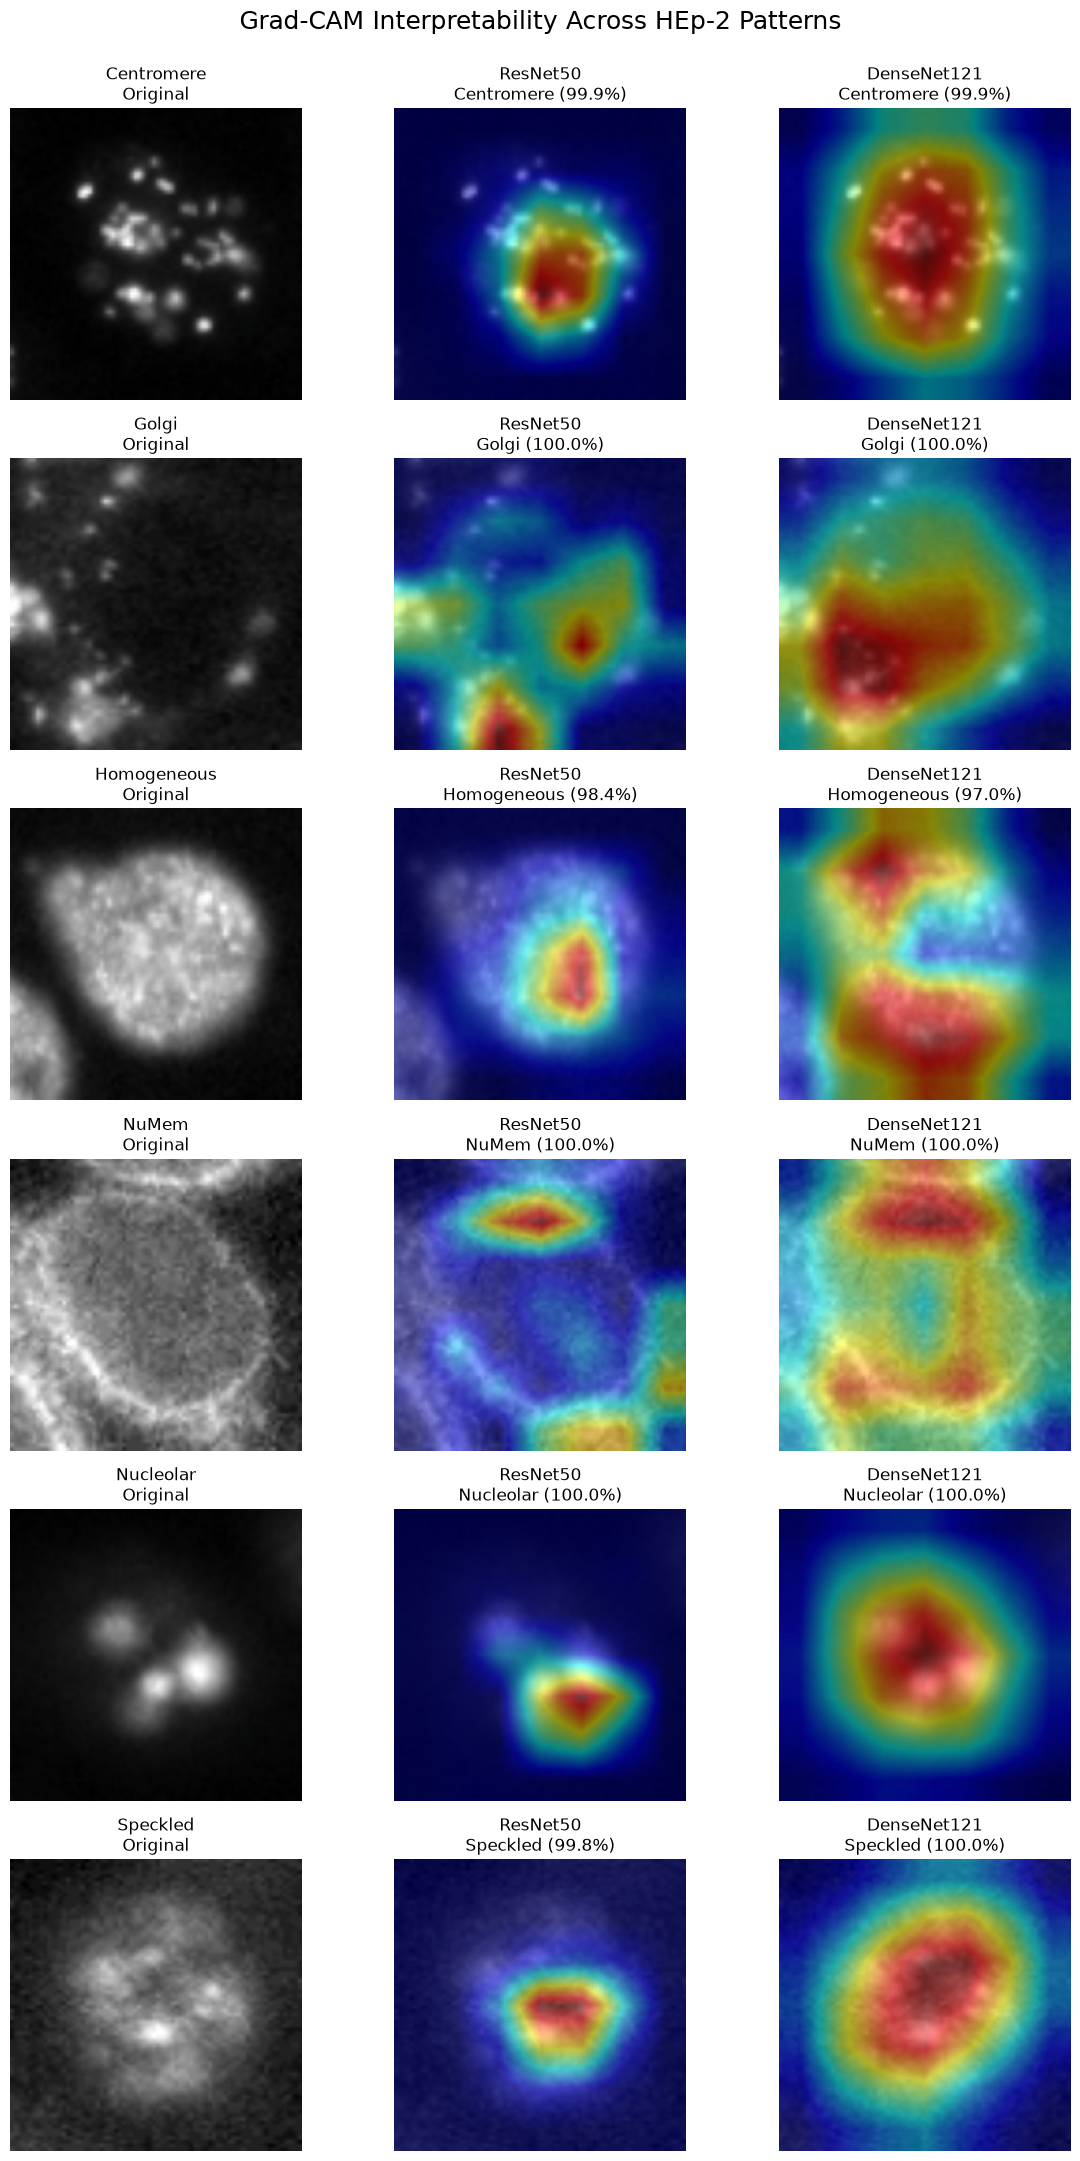

In [9]:
# ==========================================================
# Display Grad-CAM Interpretability Across All Six Classes
# ==========================================================

fig, axes = plt.subplots(
    6, 3,
    figsize=(12, 22)
)

for row, true_label in enumerate(sorted(gradcam_results.keys())):

    result = gradcam_results[true_label]

    # Original
    axes[row, 0].imshow(result["image"])
    axes[row, 0].set_title(
        f"{class_names[true_label]}\nOriginal"
    )
    axes[row, 0].axis("off")

    # ResNet50
    axes[row, 1].imshow(result["resnet_visualization"])
    axes[row, 1].set_title(
        f"ResNet50\n"
        f"{class_names[result['resnet_prediction']]} "
        f"({result['resnet_confidence'] * 100:.1f}%)"
    )
    axes[row, 1].axis("off")

    # DenseNet121
    axes[row, 2].imshow(result["densenet_visualization"])
    axes[row, 2].set_title(
        f"DenseNet121\n"
        f"{class_names[result['densenet_prediction']]} "
        f"({result['densenet_confidence'] * 100:.1f}%)"
    )
    axes[row, 2].axis("off")

plt.suptitle(
    "Grad-CAM Interpretability Across HEp-2 Patterns",
    fontsize=18
)

plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)

plt.show()

In [10]:
# ==========================================================
# Model Comparison - Generate Test Predictions
# ----------------------------------------------------------
# Generate predictions from both trained models on the
# exact same 2040-image test set.
# ==========================================================

import numpy as np
import torch

resnet_model.eval()
densenet_model.eval()

resnet_predictions = []
densenet_predictions = []
true_labels = []

with torch.no_grad():

    for idx in range(len(test_dataset)):

        image_tensor, true_label = test_dataset[idx]

        input_tensor = image_tensor.unsqueeze(0).to(device)

        # ResNet50
        resnet_output = resnet_model(input_tensor)

        resnet_prediction = torch.argmax(
            resnet_output,
            dim=1
        ).item()

        # DenseNet121
        densenet_output = densenet_model(input_tensor)

        densenet_prediction = torch.argmax(
            densenet_output,
            dim=1
        ).item()

        true_labels.append(true_label)
        resnet_predictions.append(resnet_prediction)
        densenet_predictions.append(densenet_prediction)


true_labels = np.array(true_labels)
resnet_predictions = np.array(resnet_predictions)
densenet_predictions = np.array(densenet_predictions)

print("=" * 60)
print("TEST PREDICTIONS GENERATED")
print("=" * 60)

print("Test samples:", len(true_labels))

print(
    "ResNet50 correct:",
    np.sum(resnet_predictions == true_labels)
)

print(
    "DenseNet121 correct:",
    np.sum(densenet_predictions == true_labels)
)

TEST PREDICTIONS GENERATED
Test samples: 2040
ResNet50 correct: 1978
DenseNet121 correct: 1990


In [11]:
# ==========================================================
# MODEL COMPARISON - QUANTITATIVE METRICS
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ----------------------------------------------------------
# Overall metrics
# ----------------------------------------------------------

resnet_accuracy = accuracy_score(
    true_labels,
    resnet_predictions
)

resnet_precision = precision_score(
    true_labels,
    resnet_predictions,
    average="weighted",
    zero_division=0
)

resnet_recall = recall_score(
    true_labels,
    resnet_predictions,
    average="weighted",
    zero_division=0
)

resnet_f1 = f1_score(
    true_labels,
    resnet_predictions,
    average="weighted",
    zero_division=0
)


densenet_accuracy = accuracy_score(
    true_labels,
    densenet_predictions
)

densenet_precision = precision_score(
    true_labels,
    densenet_predictions,
    average="weighted",
    zero_division=0
)

densenet_recall = recall_score(
    true_labels,
    densenet_predictions,
    average="weighted",
    zero_division=0
)

densenet_f1 = f1_score(
    true_labels,
    densenet_predictions,
    average="weighted",
    zero_division=0
)


# ----------------------------------------------------------
# Display
# ----------------------------------------------------------

print("=" * 70)
print("RESNET50 vs DENSENET121")
print("=" * 70)

print(
    f"{'Metric':<20}"
    f"{'ResNet50':>15}"
    f"{'DenseNet121':>18}"
)

print("-" * 55)

print(
    f"{'Accuracy':<20}"
    f"{resnet_accuracy * 100:>14.2f}%"
    f"{densenet_accuracy * 100:>17.2f}%"
)

print(
    f"{'Precision':<20}"
    f"{resnet_precision * 100:>14.2f}%"
    f"{densenet_precision * 100:>17.2f}%"
)

print(
    f"{'Recall':<20}"
    f"{resnet_recall * 100:>14.2f}%"
    f"{densenet_recall * 100:>17.2f}%"
)

print(
    f"{'F1-score':<20}"
    f"{resnet_f1 * 100:>14.2f}%"
    f"{densenet_f1 * 100:>17.2f}%"
)

RESNET50 vs DENSENET121
Metric                     ResNet50       DenseNet121
-------------------------------------------------------
Accuracy                     96.96%            97.55%
Precision                    96.99%            97.55%
Recall                       96.96%            97.55%
F1-score                     96.97%            97.54%


In [12]:
# ==========================================================
# PER-CLASS PERFORMANCE
# ==========================================================

print("=" * 80)
print("RESNET50 - PER-CLASS PERFORMANCE")
print("=" * 80)

print(
    classification_report(
        true_labels,
        resnet_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


print("=" * 80)
print("DENSENET121 - PER-CLASS PERFORMANCE")
print("=" * 80)

print(
    classification_report(
        true_labels,
        densenet_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

RESNET50 - PER-CLASS PERFORMANCE
              precision    recall  f1-score   support

  Centromere     0.9926    0.9757    0.9840       411
       Golgi     0.9455    0.9630    0.9541       108
 Homogeneous     0.9434    0.9813    0.9620       374
       NuMem     0.9878    0.9759    0.9818       332
   Nucleolar     0.9693    0.9718    0.9706       390
    Speckled     0.9641    0.9482    0.9561       425

    accuracy                         0.9696      2040
   macro avg     0.9671    0.9693    0.9681      2040
weighted avg     0.9699    0.9696    0.9697      2040

DENSENET121 - PER-CLASS PERFORMANCE
              precision    recall  f1-score   support

  Centromere     0.9808    0.9927    0.9867       411
       Golgi     0.9714    0.9444    0.9577       108
 Homogeneous     0.9661    0.9893    0.9775       374
       NuMem     0.9819    0.9819    0.9819       332
   Nucleolar     0.9767    0.9692    0.9730       390
    Speckled     0.9736    0.9553    0.9644       425

    accu

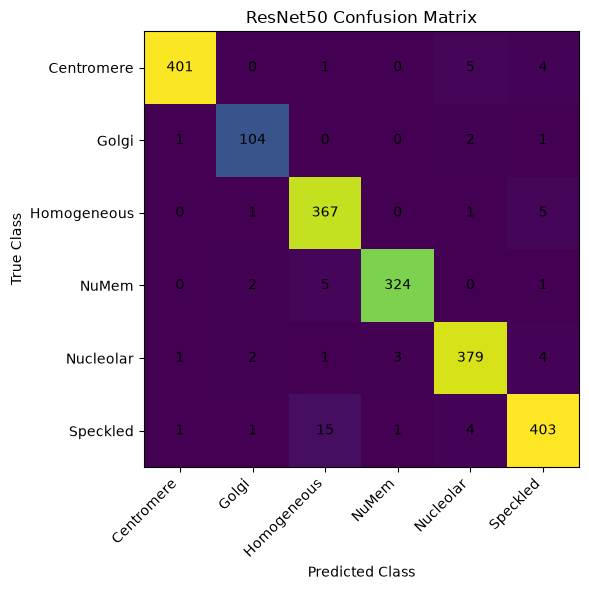

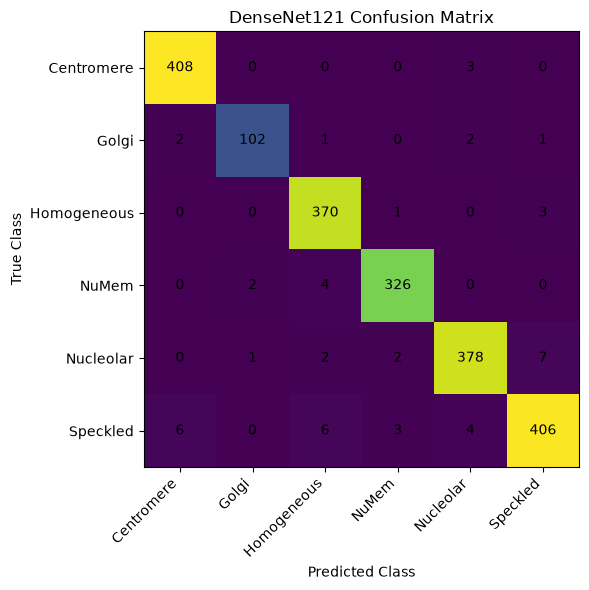

In [13]:
# ==========================================================
# CONFUSION MATRICES
# ==========================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

resnet_cm = confusion_matrix(
    true_labels,
    resnet_predictions
)

densenet_cm = confusion_matrix(
    true_labels,
    densenet_predictions
)


# ----------------------------------------------------------
# ResNet50
# ----------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.imshow(resnet_cm)

plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            resnet_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# DenseNet121
# ----------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.imshow(densenet_cm)

plt.title("DenseNet121 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            densenet_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [14]:
# ==========================================================
# FINAL MODEL COMPARISON TABLE
# ==========================================================

import pandas as pd

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "ResNet50": [
        resnet_accuracy * 100,
        resnet_precision * 100,
        resnet_recall * 100,
        resnet_f1 * 100
    ],

    "DenseNet121": [
        densenet_accuracy * 100,
        densenet_precision * 100,
        densenet_recall * 100,
        densenet_f1 * 100
    ]
})

comparison_df[
    ["ResNet50", "DenseNet121"]
] = comparison_df[
    ["ResNet50", "DenseNet121"]
].round(2)

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

display(comparison_df)

FINAL MODEL COMPARISON


,Metric,ResNet50,DenseNet121
0,Accuracy,96.96,97.55
1,Precision,96.99,97.55
2,Recall,96.96,97.55
3,F1-Score,96.97,97.54


In [15]:
# ==========================================================
# SELECT BEST PERFORMING MODEL
# ----------------------------------------------------------
# Selection is based primarily on weighted F1-score,
# while accuracy is also considered.
# ==========================================================

if densenet_f1 > resnet_f1:

    selected_model = "DenseNet121"

elif resnet_f1 > densenet_f1:

    selected_model = "ResNet50"

else:

    if densenet_accuracy > resnet_accuracy:
        selected_model = "DenseNet121"
    else:
        selected_model = "ResNet50"


print("=" * 60)
print("MODEL SELECTION")
print("=" * 60)

print("Selected model:", selected_model)

print("\nReason:")
print(
    "The model with the higher weighted F1-score is selected "
    "as the stronger overall classifier."
)

MODEL SELECTION
Selected model: DenseNet121

Reason:
The model with the higher weighted F1-score is selected as the stronger overall classifier.


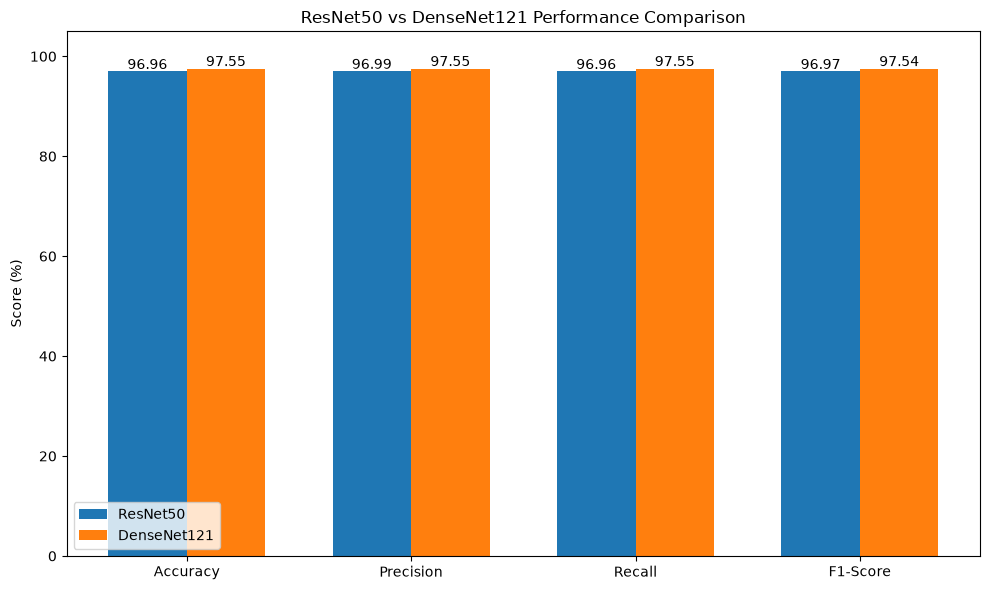

In [16]:
# ==========================================================
# VISUAL COMPARISON OF MODEL PERFORMANCE
# ==========================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

resnet_values = [
    resnet_accuracy * 100,
    resnet_precision * 100,
    resnet_recall * 100,
    resnet_f1 * 100
]

densenet_values = [
    densenet_accuracy * 100,
    densenet_precision * 100,
    densenet_recall * 100,
    densenet_f1 * 100
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    resnet_values,
    width,
    label="ResNet50"
)

plt.bar(
    x + width / 2,
    densenet_values,
    width,
    label="DenseNet121"
)

plt.xticks(x, metrics)
plt.ylabel("Score (%)")
plt.title("ResNet50 vs DenseNet121 Performance Comparison")
plt.ylim(0, 105)
plt.legend()

for i, value in enumerate(resnet_values):
    plt.text(
        i - width / 2,
        value + 0.5,
        f"{value:.2f}",
        ha="center"
    )

for i, value in enumerate(densenet_values):
    plt.text(
        i + width / 2,
        value + 0.5,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()